In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# URL alvo
url = "https://www.imovirtual.com/pt/resultados/arrendar/apartamento/porto"

# Headers atualizados para simular um navegador real e evitar bloqueio
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept-Language": "pt-PT,pt;q=0.9,en;q=0.8"
}

try:
    response = requests.get(url, headers=headers, timeout=10)
    soup = BeautifulSoup(response.text, 'html.parser')

    # Lista para guardar os apartamentos
    lista_apartamentos = []

    # O Imovirtual organiza os anúncios em tags <article> ou <li> dentro de uma lista
    # Vamos buscar todos os blocos de anúncios
    anuncios = soup.find_all('article')

    for anuncio in anuncios:
        # 1. Tentar capturar o Preço
        preco_tag = anuncio.find('span', string=lambda x: x and '€' in x)
        preco = preco_tag.get_text(strip=True) if preco_tag else "Sob consulta"

        # 2. Tentar capturar Quartos e Área (geralmente vêm em blocos de texto)
        # Vamos procurar por padrões como "T2", "80 m²", etc.
        texto_completo = anuncio.get_text(separator=' ')

        # Lógica simples para extrair Tipologia (T0, T1, T2...)
        quartos = "N/A"
        for t in ["T0", "T1", "T2", "T3", "T4", "T5"]:
            if t in texto_completo:
                quartos = t
                break

        # Lógica simples para extrair Área
        area = "N/A"
        palavras = texto_completo.split()
        for i, palavra in enumerate(palavras):
            if "m²" in palavra:
                area = palavras[i-1] + " m²" if i > 0 else palavra

        # Só adiciona se tiver pelo menos o preço ou área encontrado
        if preco != "Sob consulta" or area != "N/A":
            lista_apartamentos.append({
                "Quartos": quartos,
                "Área": area,
                "Preço": preco
            })

    # Criar o DataFrame
    df = pd.DataFrame(lista_apartamentos)

    # Verificar se a lista está vazia
    if df.empty:
        print("⚠️ Atenção: Não foram encontrados dados. O site pode estar a bloquear o acesso ou mudou a estrutura.")
    else:
        print(f"✅ Sucesso! Foram encontrados {len(df)} anúncios.")
        # Mostrar a tabela bonita do Colab
        from google.colab import data_table
        display(data_table.DataTable(df, include_index=False, num_rows_per_page=10))

except Exception as e:
    print(f"Erro ao conectar: {e}")

✅ Sucesso! Foram encontrados 37 anúncios.


,Quartos,Área,Preço
0,T1,50 m²,850 €
1,T1,70 m²,1200 €
2,T0,98 m²,215 000 €
3,T1,45 m²,1200 €
4,T3,220 m²,3500 €
5,T4,231 m²,3500 €
6,T0,35 m²,800 €
7,T1,61 m²,1350 €
8,T1,67 m²,1300 €
9,T1,67 m²,1500 €


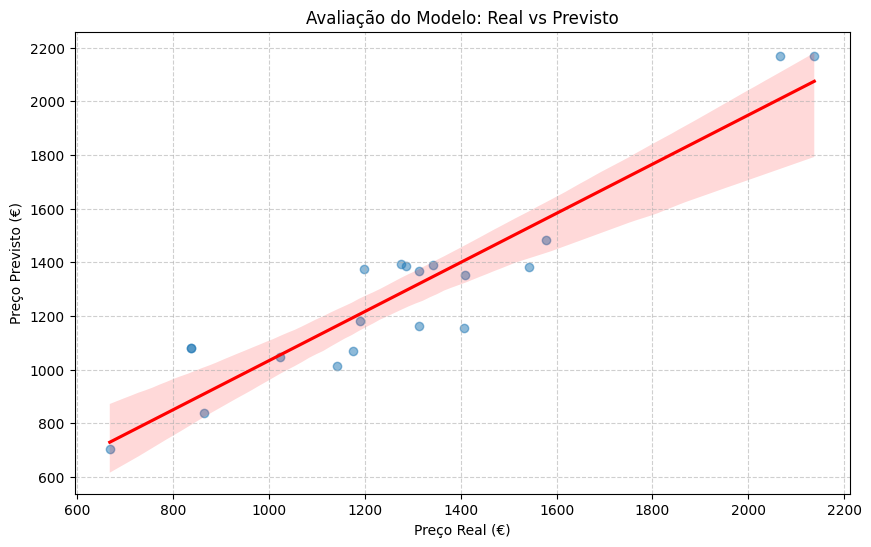


--- SIMULADOR INTERATIVO DE RENDAS (PORTO) ---


interactive(children=(IntSlider(value=85, description='area', max=250, min=40, step=5), Dropdown(description='…

NameError: name 'LinearRegression' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Limpar o aviso (Warning) e fazer uma previsão correta
def prever_preco(area, quartos):
    # Criamos um DataFrame temporário para o modelo não reclamar dos nomes das colunas
    entrada = pd.DataFrame([[area, quartos]], columns=['Area', 'Quartos'])
    preco = modelo.predict(entrada)[0]
    return preco

# 2. Visualização da Performance do Modelo
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Avaliação do Modelo: Real vs Previsto')
plt.xlabel('Preço Real (€)')
plt.ylabel('Preço Previsto (€)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Criar a interface interativa no Colab
from ipywidgets import interact, widgets

print("\n--- SIMULADOR INTERATIVO DE RENDAS (PORTO) ---")
@interact(area=(40, 250, 5), quartos=[1, 2, 3, 4, 5])
def interface(area=85, quartos=2):
    preco_estimado = prever_preco(area, quartos)
    print(f"🏠 Apartamento {quartos} com {area}m²")
    print(f"💰 Previsão de Renda: {preco_estimado:.2f}€")
    print(f"📊 Intervalo sugerido (±10%): {preco_estimado*0.9:.0f}€ - {preco_estimado*1.1:.0f}€")
    from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Treinar o Modelo de Regressão Linear
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Fazer Previsões
y_pred_lr = lr_model.predict(X_test)

# 3. Extrair a "Fórmula" do Preço
# Preço = (Coef_Area * Area) + (Coef_Quartos * Quartos) + Intercepto
coef_area = lr_model.coef_[0]
coef_quartos = lr_model.coef_[1]
intercepto = lr_model.intercept_

print("--- EQUAÇÃO DA REGRESSÃO LINEAR ---")
print(f"Preço = ({coef_area:.2f} * Área) + ({coef_quartos:.2f} * Quartos) + {intercepto:.2f}")
print("-" * 35)

# 4. Avaliação
print(f"Precisão (R²): {r2_score(y_test, y_pred_lr):.4f}")
print(f"Erro Médio (MAE): {mean_absolute_error(y_test, y_pred_lr):.2f}€")

# 5. Visualização
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_lr, color='blue', alpha=0.5, label='Previsões Linear')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfeito')
plt.title('Regressão Linear: Real vs Previsto')
plt.xlabel('Preço Real (€)')
plt.ylabel('Preço Previsto (€)')
plt.legend()
plt.show()

# 6. Comparação Simples
comparacao_linear = pd.DataFrame({
    'Real': y_test.values,
    'Previsto (Linear)': y_pred_lr.round(2)
}).head(10)

display(comparacao_linear)


--- ANÁLISE DOS COEFICIENTES (Fórmula) ---
Cada m² extra no Porto vale: 13.06€
Cada quarto extra (mesma área) vale: 67.22€
Valor Base (Intercepto): 64.21€
----------------------------------------
Precisão da Regressão Linear (R²): 0.8500
Erro Médio da Regressão Linear: 109.64€


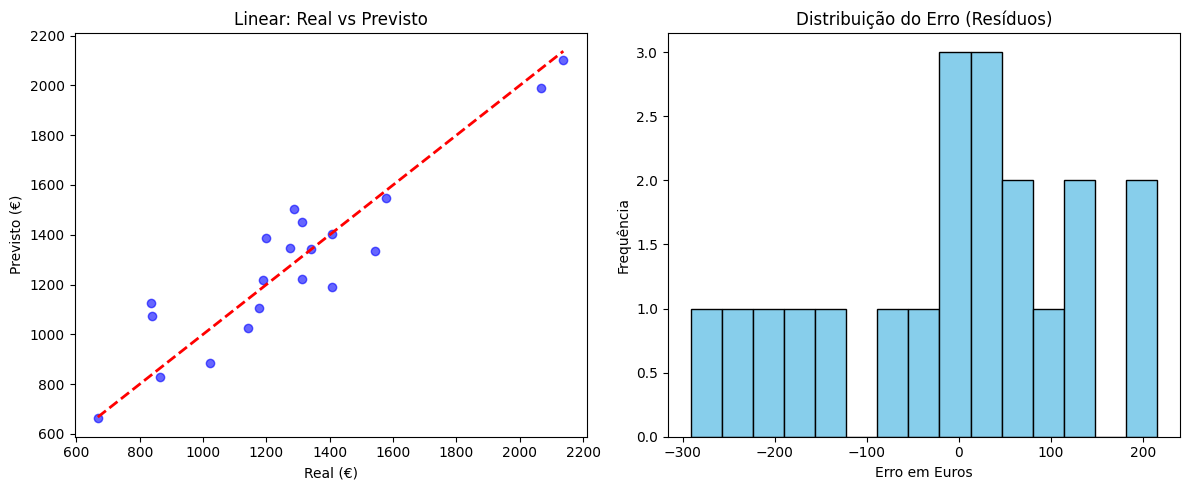

,Área,Real,Previsto (Linear)
0,69.451893,1175.245477,1105.58
1,103.350289,1578.391807,1548.24
2,95.841868,1312.517122,1450.19
3,63.404674,1141.534189,1026.61
4,40.644340,667.358843,662.18
5,90.905837,1197.146235,1385.73
6,87.025846,1541.755146,1335.07
7,78.409843,1313.178066,1222.55
8,71.097469,836.451418,1127.07
9,99.901425,1286.412908,1503.20


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Treinar o Modelo de Regressão Linear
# X_train e y_train vêm das células anteriores
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Fazer Previsões
y_pred_lr = lr_model.predict(X_test)

# 3. Extrair a "Fórmula" Matemática
# Preço = (A * Área) + (B * Quartos) + C
coef_area = lr_model.coef_[0]
coef_quartos = lr_model.coef_[1]
intercepto = lr_model.intercept_

print("--- ANÁLISE DOS COEFICIENTES (Fórmula) ---")
print(f"Cada m² extra no Porto vale: {coef_area:.2f}€")
print(f"Cada quarto extra (mesma área) vale: {coef_quartos:.2f}€")
print(f"Valor Base (Intercepto): {intercepto:.2f}€")
print("-" * 40)

# 4. Avaliação de Performance
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"Precisão da Regressão Linear (R²): {r2_lr:.4f}")
print(f"Erro Médio da Regressão Linear: {mae_lr:.2f}€")

# 5. Visualização
plt.figure(figsize=(12, 5))

# Subplot 1: Dispersão
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, color='blue', alpha=0.6, label='Previsto')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear: Real vs Previsto')
plt.xlabel('Real (€)')
plt.ylabel('Previsto (€)')

# Subplot 2: Comparação de Resíduos (Erros)
plt.subplot(1, 2, 2)
residuos = y_test - y_pred_lr
plt.hist(residuos, bins=15, color='skyblue', edgecolor='black')
plt.title('Distribuição do Erro (Resíduos)')
plt.xlabel('Erro em Euros')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

# 6. Tabela de Comparação Final
comparacao = pd.DataFrame({
    'Área': X_test['Area'].values,
    'Real': y_test.values,
    'Previsto (Linear)': y_pred_lr.round(2)
})
display(comparacao.head(10))